# Working with MNE and EEG-BIDS Part 1

In this notebook we will go over:


*   Data exploration
*   Cropping and filtering
*   EEG-BIDS



# Import packages

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import pathlib
import mne
import mne_bids

Ensure Matplotlib uses the `Qt5Agg` backend, which is the best choice for MNE-Python's interactive plotting functions. 

In [3]:
#matplotlib.use('Qt5Agg')

For some system you might want to use  `%matplotlib qt`


In [24]:
%matplotlib qt

ImportError: Failed to import any of the following Qt binding modules: PyQt6, PySide6, PyQt5, PySide2

# Data Exploration

## Load the dataset

In this tutorial, we will work with the EEG data in the MNE [sample dataset](https://mne.tools/dev/overview/datasets_index.html#contents-of-the-data-set)

The full dataset may take too long to download. For this tutorial, download the raw file from [this link] (https://drive.google.com/file/d/1-RSyaXp2Chx0zLuaAnlgK8o1VMo3enx8/view?usp=share_link) to your local directory.

## Read the raw data

In [4]:
raw_path = 'sample_audvis_raw.fif'
raw = mne.io.read_raw_fif(raw_path, preload = True)
raw

Opening raw data file sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


<Raw | sample_audvis_raw.fif, 376 x 166800 (277.7 s), ~481.7 MiB, data loaded>

## Let's visualize the raw data!

Using matplotlib as 2D backend.


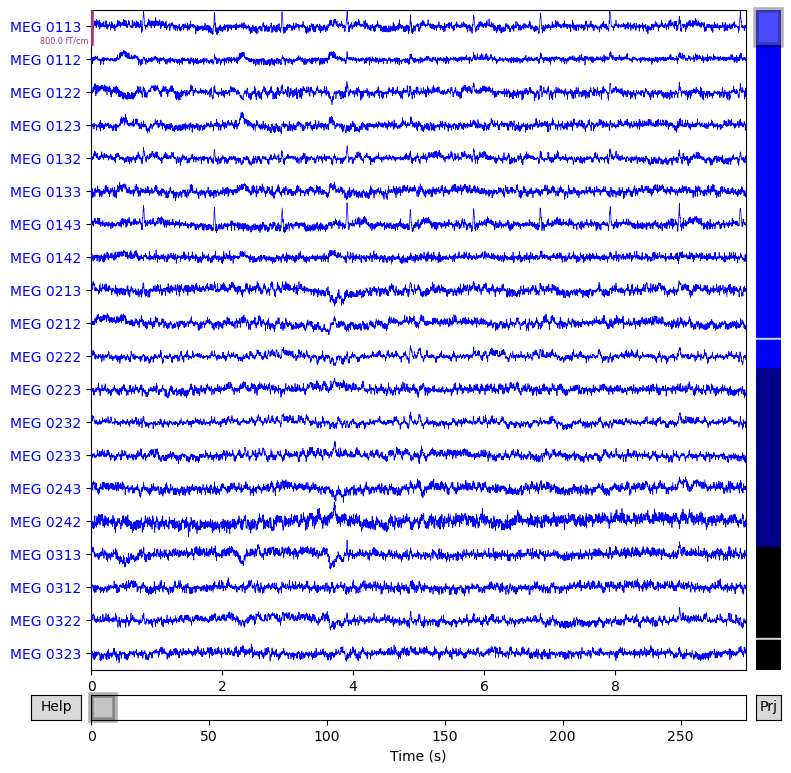

In [5]:
raw.plot();

## Extract events from the `STIM` channels

In this experiment, checkerboard patterns were presented to the subject into the left and right visual field, interspersed by tones to the left or right ear. The interval between the stimuli was 750 ms. Occasionally a smiley face was presented at the center of the visual field. The subject was asked to press a key with the right index finger as soon as possible after the appearance of the face.

We can extract information about the events in this task from the raw data.

In [6]:
events = mne.find_events(raw)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]


Six events have been identified, we can label them according to the task paradigm.

In [7]:
event_id = {
    'Auditory/Left': 1,
    'Auditory/Right': 2,
    'Visual/Left': 3,
    'Visual/Right': 4,
    'Smiley': 5,
    'Button': 32
}
event_id

{'Auditory/Left': 1,
 'Auditory/Right': 2,
 'Visual/Left': 3,
 'Visual/Right': 4,
 'Smiley': 5,
 'Button': 32}

We can plot when these events take place in time in the task paradigm

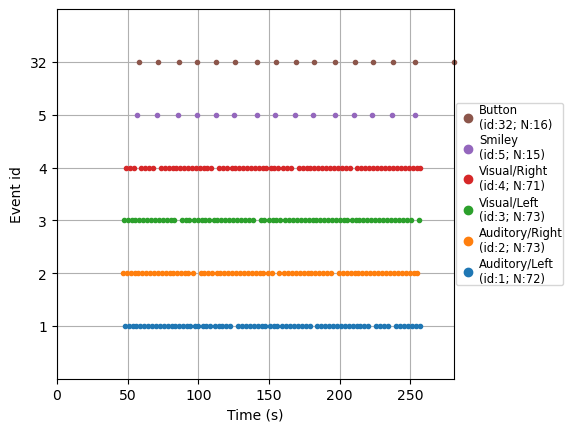

In [8]:
#rename events to plot
from mne.viz import plot_events
mne.viz.plot_events(events, event_id=event_id, sfreq=raw.info['sfreq']);

## Plot the raw data again, but add event markers

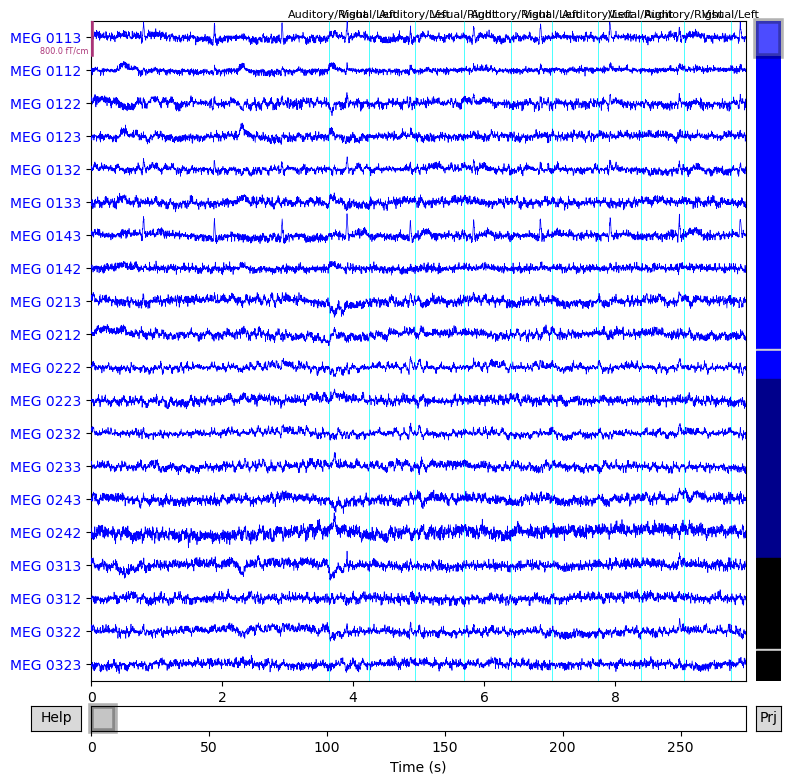

In [9]:
raw.plot(events=events, event_id=event_id);

## Gather some info about the data

In [10]:
raw.info

<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 1
 proj_name: test
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
>

In [11]:
raw.info.keys()

dict_keys(['file_id', 'events', 'hpi_results', 'hpi_meas', 'subject_info', 'device_info', 'helium_info', 'hpi_subsystem', 'proc_history', 'meas_id', 'experimenter', 'description', 'proj_id', 'proj_name', 'meas_date', 'utc_offset', 'sfreq', 'highpass', 'lowpass', 'line_freq', 'gantry_angle', 'chs', 'dev_head_t', 'ctf_head_t', 'dev_ctf_t', 'dig', 'bads', 'ch_names', 'nchan', 'projs', 'comps', 'acq_pars', 'acq_stim', 'custom_ref_applied', 'xplotter_layout', 'kit_system_id'])

In [12]:
raw.info['meas_date']

datetime.datetime(2002, 12, 3, 19, 1, 10, 720100, tzinfo=datetime.timezone.utc)

In [13]:
raw.info['sfreq']

600.614990234375

In [14]:
#Identify bad channels labbeled during acquisition
raw.info['bads']

['MEG 2443', 'EEG 053']

In [15]:
#We can also call specific channels and their properties
raw.info['chs'][0]

{'scanno': 1,
 'logno': 113,
 'kind': 1 (FIFFV_MEG_CH),
 'range': 0.00030517578125,
 'cal': 3.1600000394149674e-09,
 'coil_type': 3012 (FIFFV_COIL_VV_PLANAR_T1),
 'loc': array([-0.1066    ,  0.0464    , -0.0604    , -0.0127    ,  0.0057    ,
        -0.99990302, -0.186801  , -0.98240298, -0.0033    , -0.98232698,
         0.18674099,  0.013541  ]),
 'unit': 201 (FIFF_UNIT_T_M),
 'unit_mul': 0 (FIFF_UNITM_NONE),
 'ch_name': 'MEG 0113',
 'coord_frame': 1 (FIFFV_COORD_DEVICE)}

## Select only a subset of the channels

In [16]:
raw_eeg = raw.copy()
raw_eeg.pick_types(meg=False, eeg=True, eog=True, exclude=[])
len(raw_eeg.ch_names)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


61

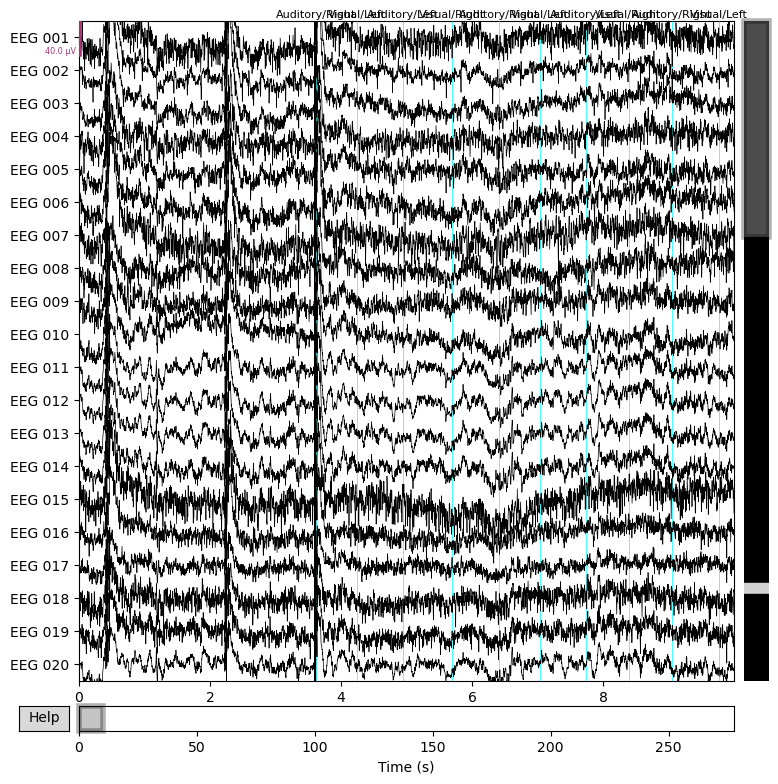

In [17]:
raw_eeg.plot(events=events, event_id=event_id);

## Visualize the sensor locations

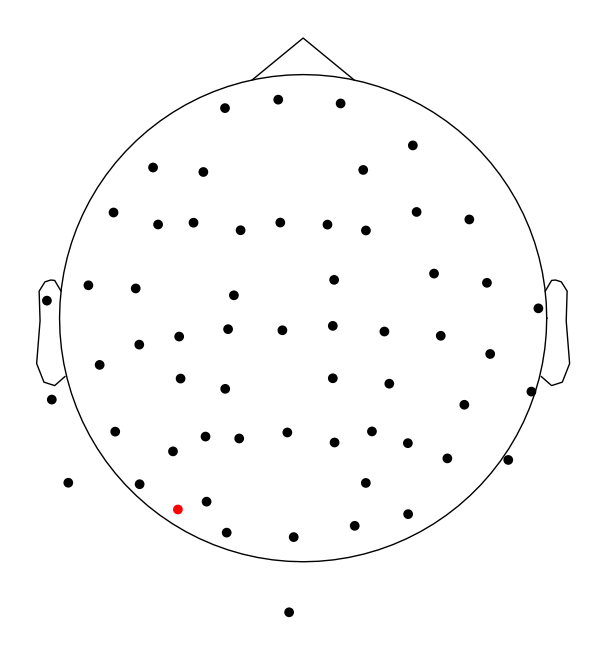

In [18]:
#In 2D
raw.plot_sensors(ch_type='eeg');

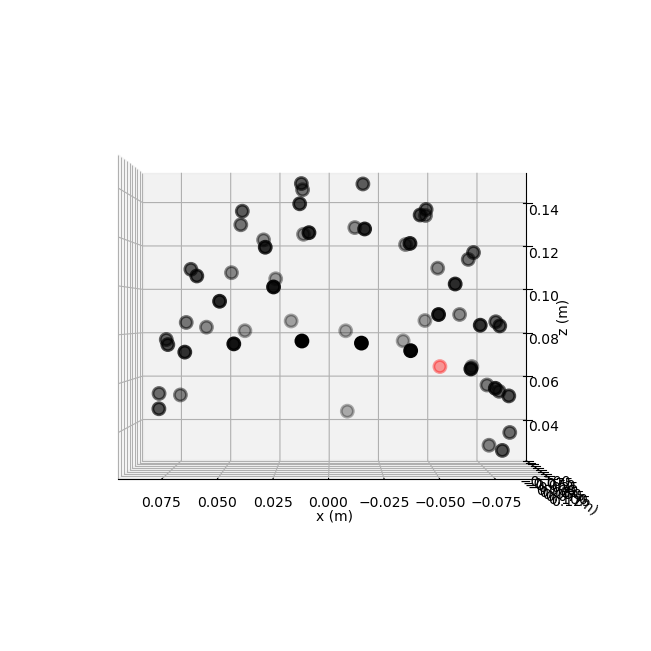

In [19]:
#In 3D
raw.plot_sensors(kind='3d', ch_type='eeg');

## Mark channels as bad

Mark an additional EEG channel as bad and view the topoplot.

In [20]:
raw.info['bads']

['MEG 2443', 'EEG 053']

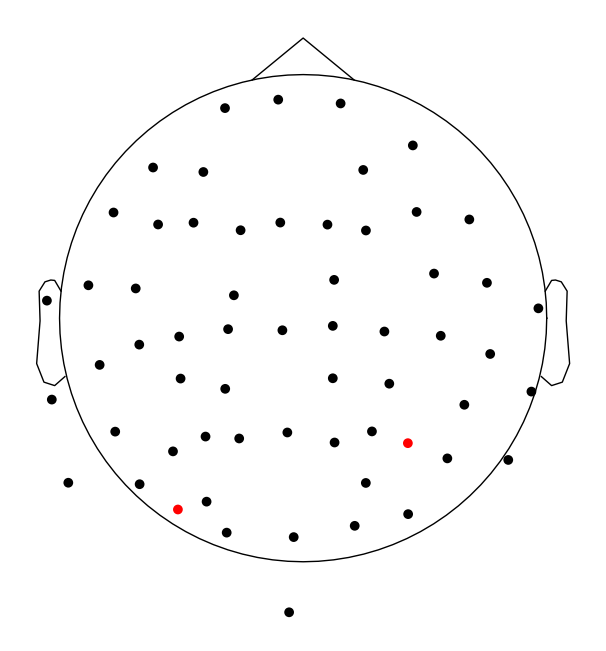

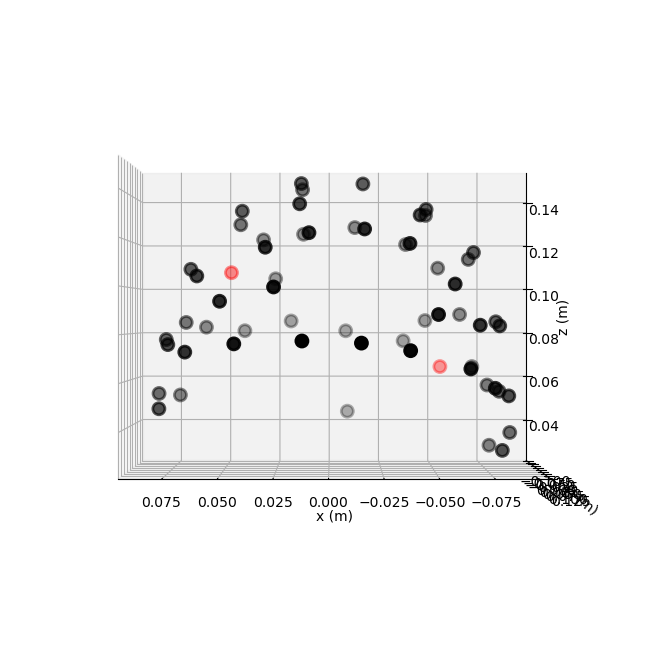

In [21]:
raw.info['bads'] += ['EEG 051']
raw.plot_sensors(ch_type='eeg');
raw.plot_sensors(kind = '3d',ch_type='eeg');

# Cropping and filtering the data

## Cropping

This EEG datset contains around 278 seconds of data. We can use only the first 100 seconds for analysis by cropping the data.

In [22]:
raw.times[-1]

np.float64(277.7136813300495)

It's best to make a copy of the loaded data first before cropping.

In [23]:
raw_cropped = raw.copy()
raw_cropped = raw_cropped.crop(tmax=100)
raw_cropped.times[-1]

np.float64(99.99916914588277)

## Filtering

We can also filter to get a specific frequency range

When we plot the power spectrum we can see frequencies ranging upto 300 Hz. 

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


/Users/lohwenliang/miniconda3/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


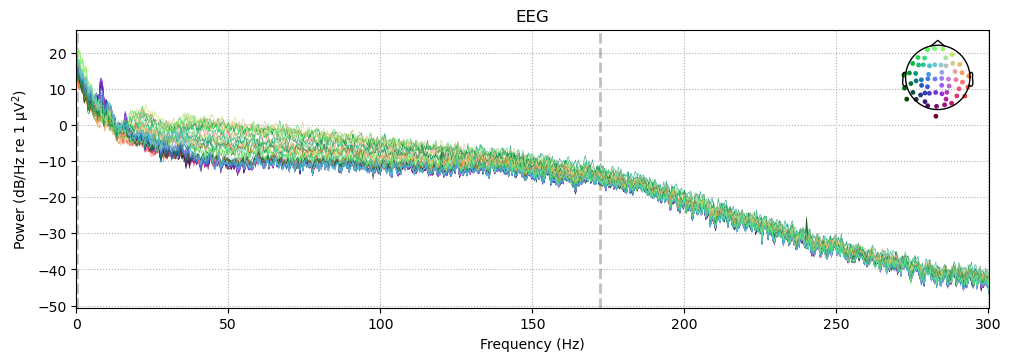

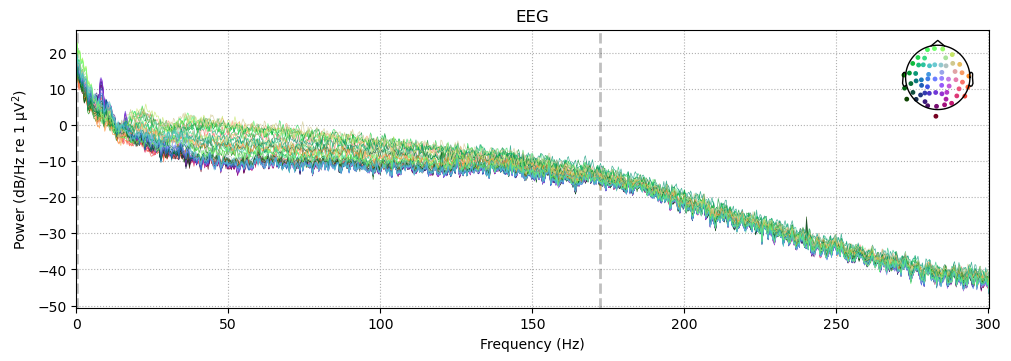

In [25]:
raw_cropped.plot_psd(picks=['eeg'])

Let's say we only want to look at signals between 0.1 and 40 Hz to focus only on some of the brain-related activity.

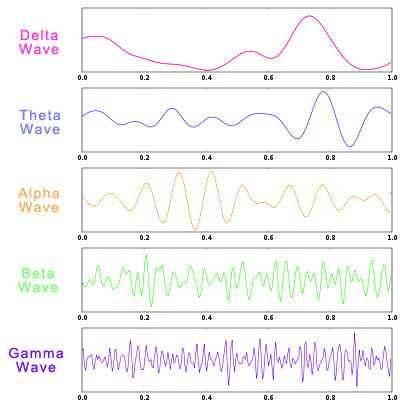

In [26]:
#Crop using a band pass filter from 1-40 Hz
raw_cropped_filtered = raw_cropped.copy()
raw_cropped_filtered = raw_cropped_filtered.filter(l_freq=1, h_freq=40)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)



### Compare before and after

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


/Users/lohwenliang/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


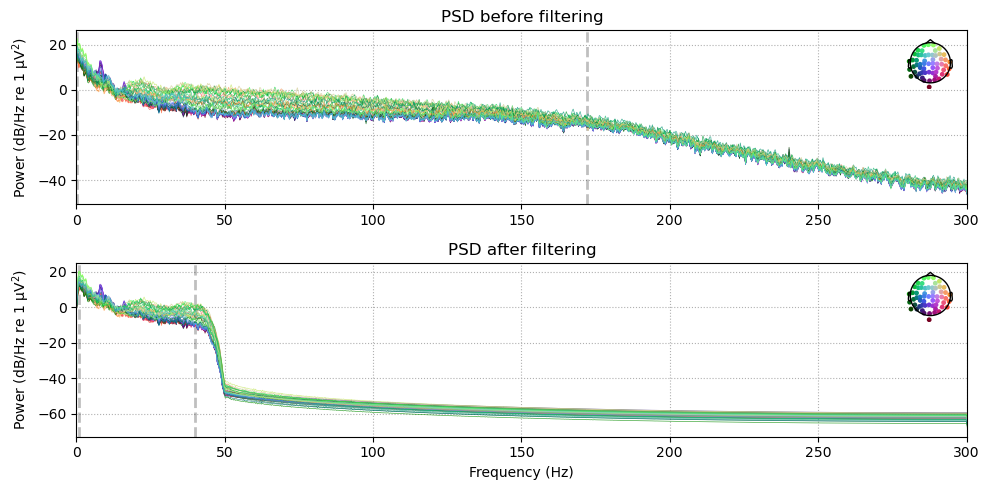

In [27]:
fig, ax = plt.subplots(2, figsize=(10,5))
raw_cropped.plot_psd(ax=ax[0],picks=['eeg'], show = False)
raw_cropped_filtered.plot_psd(ax=ax[1],picks=['eeg'], show = False)

ax[0].set_title('PSD before filtering')
ax[1].set_title('PSD after filtering')
ax[1].set_xlabel('Frequency (Hz)')
fig.set_tight_layout(True)
plt.show()

### Zoom in

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


/Users/lohwenliang/miniconda3/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


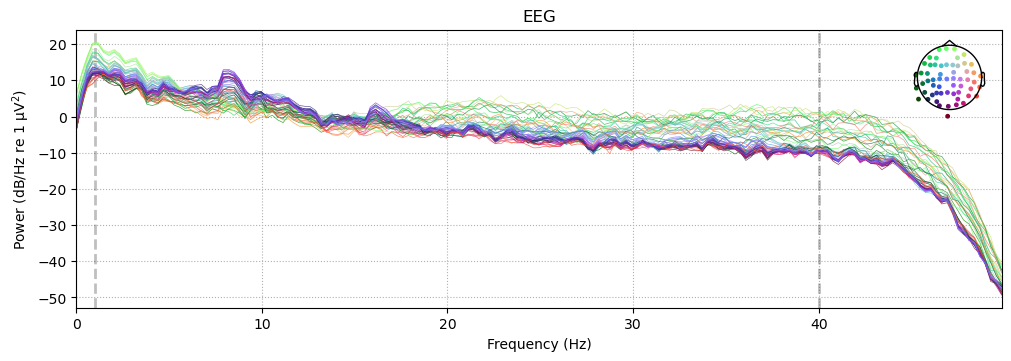

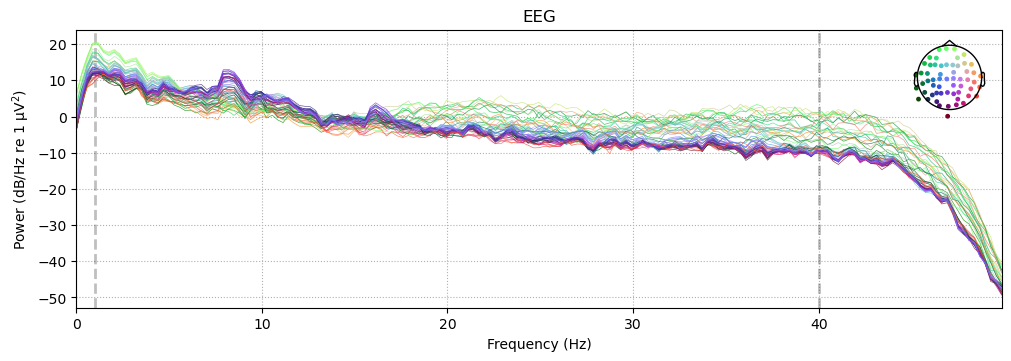

In [28]:
raw_cropped_filtered.plot_psd(picks=['eeg'], fmax=50)

# Saving the data in BIDS format


Neuroimaging experiments result in complicated data that can be arranged in many different ways. So far there is no consensus how to organize and share data obtained in neuroimaging experiments. Even two researchers working in the same lab can opt to arrange their data in a different way. Lack of consensus (or a standard) leads to misunderstandings and time wasted on rearranging data or rewriting scripts expecting certain structure.

BIDS, the Brain Imaging Data Structure, is a standard that describes how to organize neuroimaging and electrophysiological data. In particular, it defines:



*   which file formats to use
*   how to name your files
* where to place your files within a directory structure
* what additional metadata to store

The complete set of rules is written down in the [BIDS specification](https://bids-specification.readthedocs.io/en/stable/).

Here we use an extension to BIDS for electroencephalography (EEG) data, **EEG-BIDS**.

**[MNE-BIDS](https://mne.tools/mne-bids/stable/index.html)** is a Python package that allows you to read and write BIDS-compatible datasets with the help of MNE-Python.

## Write the raw data to BIDS!

We need to specify the power line frequency.

In [29]:
raw.info

<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 3 items (MEG 2443, EEG 053, EEG 051)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 1
 proj_name: test
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
>

In [34]:
#First, we need to specify the power line frequency as that is not included in the raw info

raw_cropped_filtered.info['line_freq'] = 60

#Set the path to where it will be saved
out_path = pathlib.Path('out_data/sample_BIDS')

#Set path with data specific variables for naming directory files
bids_path = mne_bids.BIDSPath(subject='01',
                              session='01',
                              task='audiovisual',
                              run='01',
                              root=out_path)
#Write raw to BIDS!
mne_bids.write_raw_bids(raw_cropped_filtered, bids_path=bids_path, events=events,
                        event_id=event_id, overwrite=True, format='FIF', allow_preload=True)

Writing 'out_data/sample_BIDS/README'...
Writing 'out_data/sample_BIDS/participants.tsv'...
Writing 'out_data/sample_BIDS/participants.json'...
Writing 'out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_coordsystem.json'...
Used Annotations descriptions: [np.str_('Auditory/Left'), np.str_('Auditory/Right'), np.str_('Button'), np.str_('Smiley'), np.str_('Visual/Left'), np.str_('Visual/Right')]
Writing 'out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_events.tsv'...
Writing 'out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_events.json'...
Writing 'out_data/sample_BIDS/dataset_description.json'...
Writing 'out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_meg.json'...
Copying data files to sub-01_ses-01_task-audiovisual_run-01_meg.fif
Writing 'out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_channels.tsv'...
Reserving possible split file sub-01_ses-01_task-audiovisual_run-01_s

/var/folders/6m/t6dggzhs27x_bcr33wbqys5c0000gn/T/ipykernel_4187/961287177.py:15: RuntimeWarning: Omitted 173 annotation(s) that were outside data range.
  mne_bids.write_raw_bids(raw_cropped_filtered, bids_path=bids_path, events=events,


Closing /Users/lohwenliang/mne_eeg/out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_meg.fif
[done]
Writing 'out_data/sample_BIDS/sub-01/ses-01/sub-01_ses-01_scans.tsv'...
Wrote out_data/sample_BIDS/sub-01/ses-01/sub-01_ses-01_scans.tsv entry with meg/sub-01_ses-01_task-audiovisual_run-01_meg.fif.


BIDSPath(
root: out_data/sample_BIDS
datatype: meg
basename: sub-01_ses-01_task-audiovisual_run-01_meg.fif)

### Print the created file & directory structure

In [35]:
mne_bids.print_dir_tree(out_path)

|sample_BIDS/
|--- .DS_Store
|--- README
|--- dataset_description.json
|--- participants.json
|--- participants.tsv
|--- sub-01/
|------ .DS_Store
|------ ses-01/
|--------- .DS_Store
|--------- sub-01_ses-01_scans.tsv
|--------- meg/
|------------ sub-01_ses-01_coordsystem.json
|------------ sub-01_ses-01_task-audiovisual_run-01_channels.tsv
|------------ sub-01_ses-01_task-audiovisual_run-01_events.json
|------------ sub-01_ses-01_task-audiovisual_run-01_events.tsv
|------------ sub-01_ses-01_task-audiovisual_run-01_meg.fif
|------------ sub-01_ses-01_task-audiovisual_run-01_meg.json


### Generate a data summary

In [36]:
print(mne_bids.make_report(out_path))

Summarizing participants.tsv out_data/sample_BIDS/participants.tsv...
Summarizing scans.tsv files [PosixPath('out_data/sample_BIDS/sub-01/ses-01/sub-01_ses-01_scans.tsv')]...
The participant template found: sex were all unknown;
handedness were all unknown;
ages all unknown
 The [Unspecified] dataset was created by [Unspecified1], and [Unspecified2] and
conforms to BIDS version 1.9.0. This report was generated with MNE-BIDS
(https://doi.org/10.21105/joss.01896). The dataset consists of 1 participants
(sex were all unknown; handedness were all unknown; ages all unknown) and 1
recording sessions: 01. Data was recorded using an MEG system (Elekta) sampled
at 600.61 Hz with line noise at 60.0 Hz. The following software filters were
applied during recording: SpatialCompensation. There was 1 scan in total.
Recording durations ranged from 100.0 to 100.0 seconds (mean = 100.0, std =
0.0), for a total of 100.0 seconds of data recorded over all scans. For each
dataset, there were on average 376.

## Reading BIDS data

Opening raw data file out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_meg.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 85861 =     42.956 ...   142.955 secs
Ready.
Reading channel info from out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_channels.tsv.


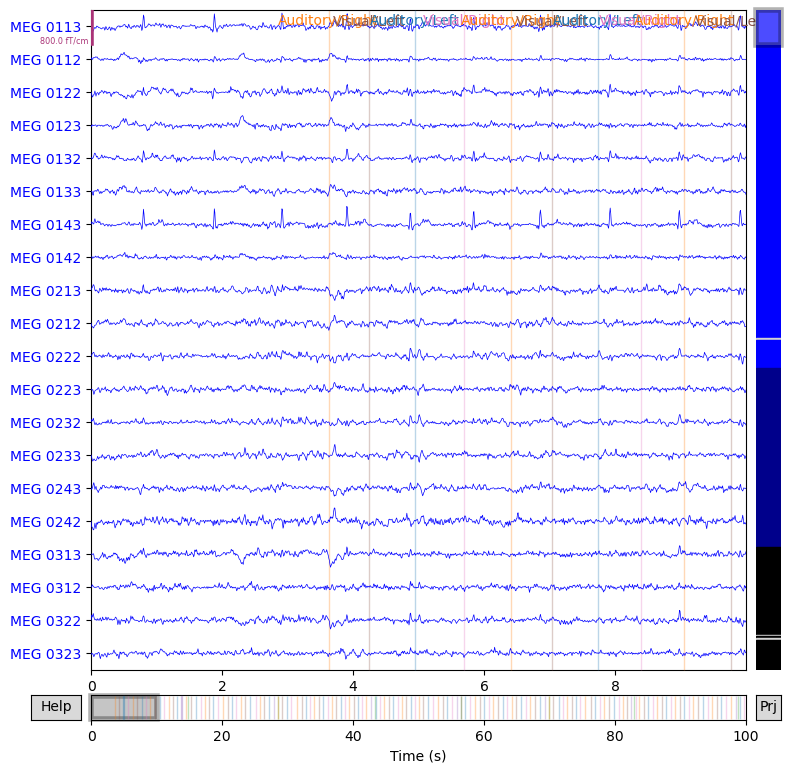

In [37]:
bids_root = pathlib.Path('out_data/sample_BIDS')

bids_path = mne_bids.BIDSPath(subject='01',
                              session='01',
                              task='audiovisual',
                              run='01',
                              datatype='meg',
                              root=bids_root)

raw_BIDS = mne_bids.read_raw_bids(bids_path)
raw_BIDS.plot();

# Refrences

**MNE-Python** - 
Alexandre Gramfort, Martin Luessi, Eric Larson, Denis A. Engemann, Daniel Strohmeier, Christian Brodbeck, Roman Goj, Mainak Jas, Teon Brooks, Lauri Parkkonen, and Matti S. Hämäläinen. MEG and EEG data analysis with MNE-Python. Frontiers in Neuroscience, 7(267):1–13, 2013. doi:10.3389/fnins.2013.00267.

**BIDS**
Gorgolewski, K.J., Auer, T., Calhoun, V.D., Craddock, R.C., Das, S., Duff, E.P., Flandin, G., Ghosh, S.S., Glatard, T., Halchenko, Y.O., Handwerker, D.A., Hanke, M., Keator, D., Li, X., Michael, Z., Maumet, C., Nichols, B.N., Nichols, T.E., Pellman, J., Poline, J.-B., Rokem, A., Schaefer, G., Sochat, V., Triplett, W., Turner, J.A., Varoquaux, G., Poldrack, R.A. (2016). The brain imaging data structure, a format for organizing and describing outputs of neuroimaging experiments. Scientific Data, 3 (160044). doi:10.1038/sdata.2016.44

**MNE-BIDS** - 
Appelhoff, S., Sanderson, M., Brooks, T., Vliet, M., Quentin, R., Holdgraf, C., Chaumon, M., Mikulan, E., Tavabi, K., Höchenberger, R., Welke, D., Brunner, C., Rockhill, A., Larson, E., Gramfort, A., & Jas, M. (2019). MNE-BIDS: Organizing electrophysiological data into the BIDS format and facilitating their analysis. *Journal of Open Source Software*, 4:1896. DOI: 10.21105/joss.01896

**EEG-BIDS** - Pernet, C. R., Appelhoff, S., Gorgolewski, K.J., Flandin, G., Phillips, C., Delorme, A., Oostenveld, R. (2019). EEG-BIDS, an extension to the brain imaging data structure for electroencephalography. Scientific data, 6 (103). doi:10.1038/s41597-019-0104-8

**MNE EEG-BIDS**
Niso, G., Gorgolewski, K., Bock, E. et al. MEG-BIDS, the brain imaging data structure extended to magnetoencephalography. *Sci Data* 5, 180110 (2018). https://doi.org/10.1038/sdata.2018.110



## Exercise #1

1) How many channels do you have for each type of sensors?


In [ ]:
307 MEG channels, 61 EEG channels, 1 EOG channel and 9 stimulus channels

2) What is the sampling frequency?

In [ ]:
600.61 Hz

3) Have the data been filtered?

In [ ]:
Yes

4) What is the frequency of the line noise?

In [ ]:
60 Hz

5) Is there any bad channel?

In [ ]:
Yes, there were 2 bad channels